<Axes: >

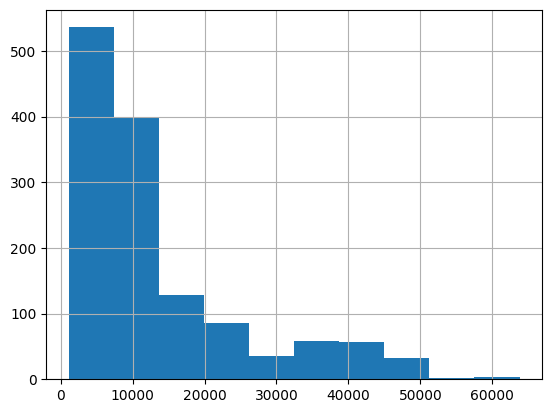

In [1]:
import pandas as pd

insurance = pd.read_csv("insurance.csv")

insurance['charges'].describe()
insurance['charges'].hist()
#credit_train = credit_rand.iloc[0:901]
#credit_test = credit_rand.iloc[901:]

In [2]:
print(insurance.corr(numeric_only=True))

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


array([[<Axes: xlabel='age', ylabel='age'>,
        <Axes: xlabel='bmi', ylabel='age'>,
        <Axes: xlabel='children', ylabel='age'>,
        <Axes: xlabel='charges', ylabel='age'>],
       [<Axes: xlabel='age', ylabel='bmi'>,
        <Axes: xlabel='bmi', ylabel='bmi'>,
        <Axes: xlabel='children', ylabel='bmi'>,
        <Axes: xlabel='charges', ylabel='bmi'>],
       [<Axes: xlabel='age', ylabel='children'>,
        <Axes: xlabel='bmi', ylabel='children'>,
        <Axes: xlabel='children', ylabel='children'>,
        <Axes: xlabel='charges', ylabel='children'>],
       [<Axes: xlabel='age', ylabel='charges'>,
        <Axes: xlabel='bmi', ylabel='charges'>,
        <Axes: xlabel='children', ylabel='charges'>,
        <Axes: xlabel='charges', ylabel='charges'>]], dtype=object)

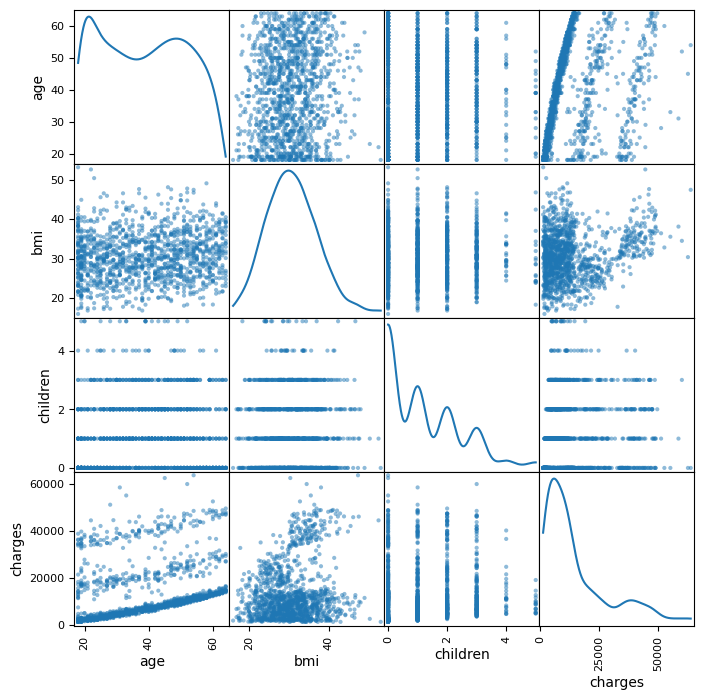

In [3]:
from pandas.plotting import scatter_matrix
scatter_matrix(insurance, figsize=(8, 8), diagonal='kde')
#RELAÇÕES: age and charges || bmi and charges

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# alvo
y = insurance['charges']

# atributos
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']
X = insurance[numeric_features + categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features),
    ],
    remainder='passthrough',  # mantém colunas numéricas sem alteração
)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression()),
])
model.fit(X, y)

feature_names = model.named_steps['preprocessor'].get_feature_names_out()
print("Intercepto:", model.named_steps['regressor'].intercept_)
print("Coeficientes:")
for name, coef in zip(feature_names, model.named_steps['regressor'].coef_):
    print(f"  {name}: {coef}")

Intercepto: -11938.538576166997
Coeficientes:
  cat__sex_male: -131.31435939510246
  cat__smoker_yes: 23848.53454191281
  cat__region_northwest: -352.96389942464344
  cat__region_southeast: -1035.02204938782
  cat__region_southwest: -960.0509913008344
  remainder__age: 256.85635253734654
  remainder__bmi: 339.1934536108347
  remainder__children: 475.5005451491363


In [5]:
"""
Transcrevendo o ins_model para o python, relacionamos as 6 variaveis independentes ao total medical charges
e a leitura a ser feita já está em valores do quanto o charge aumenta para cada variável, 
então por exemplo, envelhecer ano após ano adiciona 256, em média, no charge, sendo o mais significativo a variável fumar,
com impressionantes 23848 de valor de beta.

as outras não numéricas foram atribuidas valores atrvés do dummy coding (uma categoria vira base, não ganha coluna)

relações lineares são intuitivas para associarmos, como as citadas acima, talvez a não tão evidente é a de filhos, que não necessariamente degradam a saúde
e causam maior custo pro plano, mas ao adicionar um filho no convenio, aumentam as depesas.
"""

'\nTranscrevendo o ins_model para o python, relacionamos as 6 variaveis independentes ao total medical charges\ne a leitura a ser feita já está em valores do quanto o charge aumenta para cada variável, \nentão por exemplo, envelhecer ano após ano adiciona 256, em média, no charge, sendo o mais significativo a variável fumar,\ncom impressionantes 23848 de valor de beta.\n\nas outras não numéricas foram atribuidas valores atrvés do dummy coding (uma categoria vira base, não ganha coluna)\n\nrelações lineares são intuitivas para associarmos, como as citadas acima, talvez a não tão evidente é a de filhos, que não necessariamente degradam a saúde\ne causam maior custo pro plano, mas ao adicionar um filho no convenio, aumentam as depesas.\n'

In [6]:
from sklearn.metrics import r2_score, root_mean_squared_error

# Predição no treino (exemplo)
y_pred = model.predict(X)

print("R²:", r2_score(y, y_pred))
print("RMSE:", root_mean_squared_error(y, y_pred))

R²: 0.7509130345985207
RMSE: 6041.6796511744515


In [7]:
import statsmodels.formula.api as smf
import pandas as pd

model = smf.ols('charges ~ age + children + bmi + sex + smoker + region', data=insurance).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:39:30   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -1.194e+04    

In [8]:
"""
Tratando-se do quão bem o modelo deu fit com os dados
o valor residual é igual ao valor real menos o previsto, mas não é mostrado nessa adptação
mas conseguimos com o método dos Rs quadrados, ver o quão bem nosso modelo linear conseguiu explicar os dados
pois 75% dos da variação na variável dependente é explicada pelo nosso modelo
"""

'\nTratando-se do quão bem o modelo deu fit com os dados\no valor residual é igual ao valor real menos o previsto, mas não é mostrado nessa adptação\nmas conseguimos com o método dos Rs quadrados, ver o quão bem nosso modelo linear conseguiu explicar os dados\npois 75% dos da variação na variável dependente é explicada pelo nosso modelo\n'

In [9]:
insurance_mod = insurance
insurance_mod['age2'] = insurance_mod['age'] ** 2
insurance_mod['bmi30'] = (insurance_mod['bmi'] >= 30).astype(int)

In [10]:
import statsmodels.formula.api as smf

formula = 'charges ~ age + age2 + children + bmi + sex + bmi30*smoker + region'

model2 = smf.ols(formula=formula, data=insurance_mod).fit()

print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     781.7
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:39:30   Log-Likelihood:                -13131.
No. Observations:                1338   AIC:                         2.629e+04
Df Residuals:                    1326   BIC:                         2.635e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             134.2509   1

In [11]:
"""
Chegamos no mesmo resultado do LANTZ, adaptando a visão do R com a lib
statsmodels.formula.api, onde comparado com o primeiro, saltamos de 0,751 para 0,866
uma melhora expressiva ao testarmos a hipótese final do capitulo de
'e se algumas features tiverem um impacto combinado numa variável dependente' -> interação
ex: fumar e obsidade
onde as melhorias de criação de termo não linear para idade, indicador de obesidade e interação de obsidade+fumar
contribuiram para capturas padrões que o linear puro não pegou:
-idade tende a ter efeito não linear
-IMC mostra um efeito de limiar forte quando IMC ≥ 30
-fumar e ser obeso, interagem, o impacto de ser fumante é ainda maior quando a pessoa é obesa (de 13k de custo para 19k de custo)
"""

"\nChegamos no mesmo resultado do LANTZ, adaptando a visão do R com a lib\nstatsmodels.formula.api, onde comparado com o primeiro, saltamos de 0,751 para 0,866\numa melhora expressiva ao testarmos a hipótese final do capitulo de\n'e se algumas features tiverem um impacto combinado numa variável dependente' -> interação\nex: fumar e obsidade\nonde as melhorias de criação de termo não linear para idade, indicador de obesidade e interação de obsidade+fumar\ncontribuiram para capturas padrões que o linear puro não pegou:\n-idade tende a ter efeito não linear\n-IMC mostra um efeito de limiar forte quando IMC ≥ 30\n-fumar e ser obeso, interagem, o impacto de ser fumante é ainda maior quando a pessoa é obesa (de 13k de custo para 19k de custo)\n"